# Semana 2 Clase 2

### Datos, limpieza y análisis exploratorio

En problemas reales, rara vez los datos llegan listos. Antes de modelar, casi siempre hay que revisar:

- nombres de columnas;
- tipos de datos;
- valores faltantes;
- duplicados;
- errores de captura;
- variables categóricas;
- variables numéricas;
- variables derivadas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
ruta = 'https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2020.csv'
df = pd.read_csv(ruta)
df

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp
0,Aguascalientes,AG,Noreste,7,86,0
1,Baja California,BC,Noroeste,298,2563,106
2,Baja California Sur,BS,Noroeste,7,71,0
3,Campeche,CM,Sureste,7,69,0
4,Coahuila de Zaragoza,CO,Noreste,33,209,0
5,Colima,CL,Occidente,105,588,1
6,Chiapas,CS,Sureste,74,461,1
7,Chihuahua,CH,Noroeste,357,3107,4
8,CDMX,CX,Centro-Sur,144,1196,0
9,Durango,DG,Noroeste,20,147,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Estado       32 non-null     object
 1   Abreviatura  31 non-null     object
 2   Regiones     32 non-null     object
 3   Mujeres      32 non-null     int64 
 4   Hombres      32 non-null     int64 
 5   No_esp       32 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 1.6+ KB


El método .describe() genera estadísticas descriptivas que resumen la tendencia central, la dispersión y la forma de la distribución de un conjunto de datos, excluyendo los valores NaN (nulos).

Por defecto, solo analiza las columnas numéricas.

In [7]:
df.describe()

,Mujeres,Hombres,No_esp
count,32.000000,32.000000,32.000000
mean,123.656250,1010.500000,15.000000
std,140.782516,1035.215421,40.452282
min,7.000000,60.000000,0.000000
25%,31.500000,207.250000,0.000000
50%,78.000000,747.000000,1.500000
75%,140.250000,1234.250000,7.500000
max,640.000000,4524.000000,206.000000


Revisión de valores faltantes

In [9]:
df.isna().sum()     #cuenta cuántos valores faltantes hay en cada columna.

Estado         0
Abreviatura    1
Regiones       0
Mujeres        0
Hombres        0
No_esp         0
dtype: int64

In [10]:
print("Número de filas duplicadas:")
print(df.duplicated().sum())

Número de filas duplicadas:
0


In [11]:
df["Total"] = df["Mujeres"] + df["Hombres"] + df["No_esp"]

df

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total
0,Aguascalientes,AG,Noreste,7,86,0,93
1,Baja California,BC,Noroeste,298,2563,106,2967
2,Baja California Sur,BS,Noroeste,7,71,0,78
3,Campeche,CM,Sureste,7,69,0,76
4,Coahuila de Zaragoza,CO,Noreste,33,209,0,242
5,Colima,CL,Occidente,105,588,1,694
6,Chiapas,CS,Sureste,74,461,1,536
7,Chihuahua,CH,Noroeste,357,3107,4,3468
8,CDMX,CX,Centro-Sur,144,1196,0,1340
9,Durango,DG,Noroeste,20,147,1,168


También podemos calcular el porcentaje correspondiente a cada grupo.

$$
\text{Porcentaje de mujeres} = \frac{\text{Mujeres}}{\text{Total}} \times 100.
$$

$$
\text{Porcentaje de hombres} = \frac{\text{Hombres}}{\text{Total}} \times 100.
$$

In [13]:
df["Porcentaje_mujeres"] = 100 * df["Mujeres"] / df["Total"]
df["Porcentaje_hombres"] = 100 * df["Hombres"] / df["Total"]
df["Porcentaje_no_esp"] = 100 * df["No_esp"] / df["Total"]

df.head()

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total,Porcentaje_mujeres,Porcentaje_hombres,Porcentaje_no_esp
0,Aguascalientes,AG,Noreste,7,86,0,93,7.526882,92.473118,0.000000
1,Baja California,BC,Noroeste,298,2563,106,2967,10.043815,86.383552,3.572632
2,Baja California Sur,BS,Noroeste,7,71,0,78,8.974359,91.025641,0.000000
3,Campeche,CM,Sureste,7,69,0,76,9.210526,90.789474,0.000000
4,Coahuila de Zaragoza,CO,Noreste,33,209,0,242,13.636364,86.363636,0.000000


Ordenar los datos

In [15]:
df_ordenado = df.sort_values(by="Total", ascending=False)

df_ordenado.head(10)

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total,Porcentaje_mujeres,Porcentaje_hombres,Porcentaje_no_esp
10,Guanajuato,GT,Noreste,640,4524,206,5370,11.918063,84.245810,3.836127
7,Chihuahua,CH,Noroeste,357,3107,4,3468,10.294118,89.590542,0.115340
14,Mexico,EM,Occidente,432,2648,9,3089,13.985108,85.723535,0.291356
1,Baja California,BC,Noroeste,298,2563,106,2967,10.043815,86.383552,3.572632
15,Michoacan,MI,Occidente,248,2149,3,2400,10.333333,89.541667,0.125000
13,Jalisco,JC,Noroeste,245,1989,7,2241,10.932619,88.755020,0.312361
25,Sonora,SO,Noroeste,93,1449,40,1582,5.878635,91.592920,2.528445
11,Guerrero,GR,Centro-Sur,154,1349,4,1507,10.218978,89.515594,0.265428
8,CDMX,CX,Centro-Sur,144,1196,0,1340,10.746269,89.253731,0.000000
31,Zacatecas,ZA,Noreste,114,1088,42,1244,9.163987,87.459807,3.376206


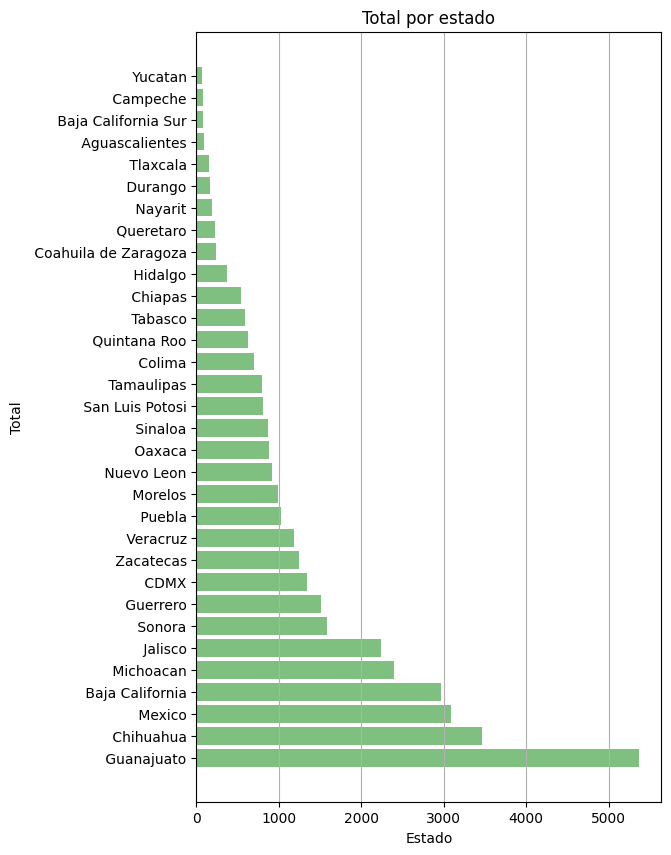

In [25]:
plt.figure(figsize=(6, 10))

plt.barh(df_ordenado["Estado"], df_ordenado["Total"],color='green', alpha=0.5)

plt.xlabel("Estado")
plt.ylabel("Total")
plt.title("Total por estado")
plt.xticks()
plt.grid(axis="x")

plt.show()

## Agrupación por región

In [27]:
df_region = df.groupby("Regiones")["Total"].sum().reset_index()

df_region

,Regiones,Total
0,Centro-Sur,5020
1,Noreste,9698
2,Noroeste,11555
3,Occidente,6549
4,Sureste,3951


In [28]:
df_region = df_region.sort_values(by="Total", ascending=False)

df_region

,Regiones,Total
2,Noroeste,11555
1,Noreste,9698
3,Occidente,6549
0,Centro-Sur,5020
4,Sureste,3951


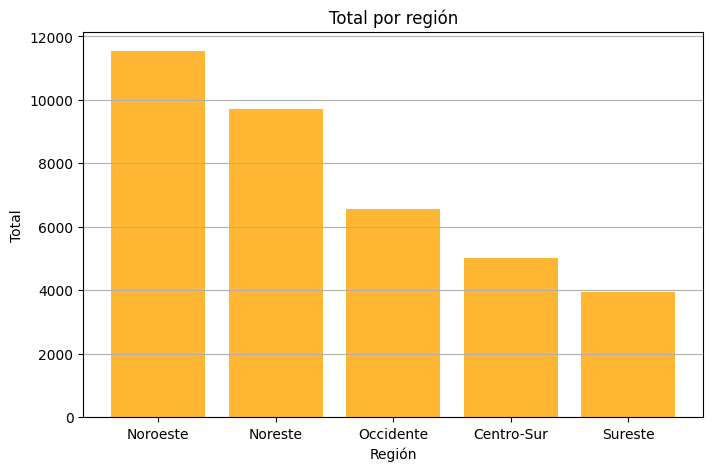

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(df_region["Regiones"], df_region["Total"], color='orange', alpha=0.8)

plt.xlabel("Región")
plt.ylabel("Total")
plt.title("Total por región")
plt.xticks()
plt.grid(axis="y")

plt.show()

Podemos estudiar la composición total por sexo:

In [34]:
totales_sexo = df[["Mujeres", "Hombres", "No_esp"]].sum()

totales_sexo

Mujeres     3957
Hombres    32336
No_esp       480
dtype: int64

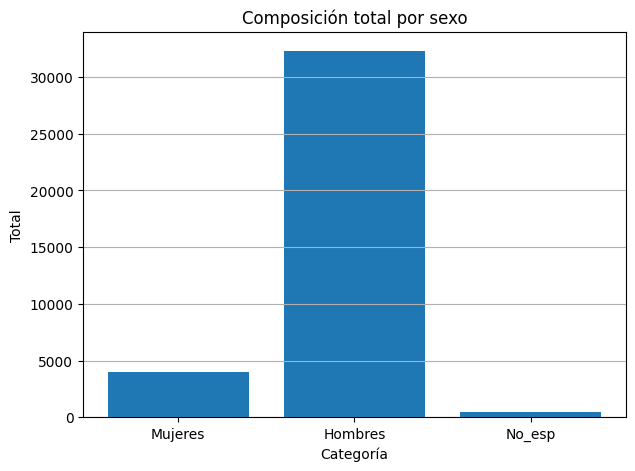

In [35]:
plt.figure(figsize=(7, 5))

plt.bar(totales_sexo.index, totales_sexo.values)

plt.xlabel("Categoría")
plt.ylabel("Total")
plt.title("Composición total por sexo")
plt.grid(axis="y")

plt.show()

Gráfica de barras apiladas por región

In [37]:
df_region_sexo = df.groupby("Regiones")[["Mujeres", "Hombres", "No_esp"]].sum()

df_region_sexo

,Mujeres,Hombres,No_esp
Regiones,,,
Centro-Sur,534,4477,9
Noreste,1049,8365,284
Noroeste,1082,10302,171
Occidente,827,5709,13
Sureste,465,3483,3


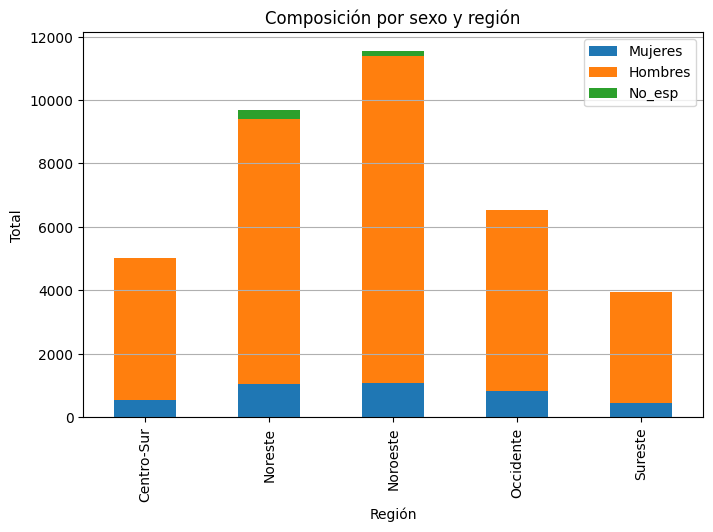

In [40]:
df_region_sexo.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.xlabel("Región")
plt.ylabel("Total")
plt.title("Composición por sexo y región")
plt.xticks()
plt.grid(axis="y")

plt.show()

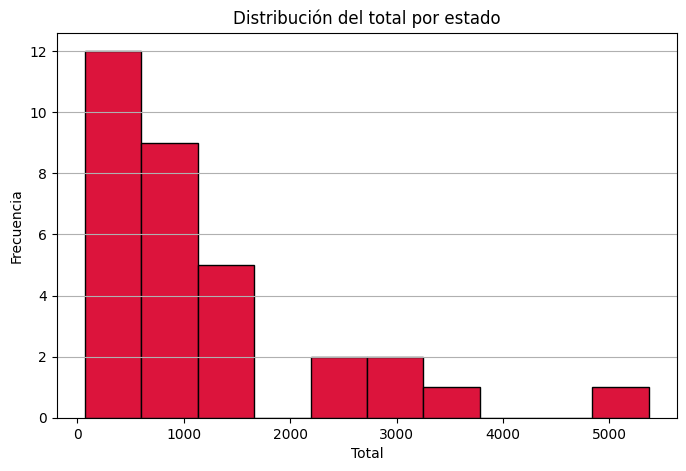

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total"], bins=10, color='crimson',edgecolor='black')

plt.xlabel("Total")
plt.ylabel("Frecuencia")
plt.title("Distribución del total por estado")
plt.grid(axis="y")

plt.show()

El histograma permite ver si la mayoría de los estados se concentran en valores bajos, medios o altos.

<Figure size 800x500 with 0 Axes>

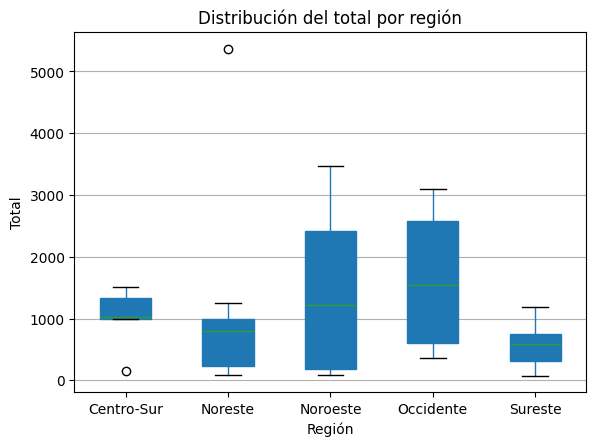

In [51]:
plt.figure(figsize=(8, 5))

df.boxplot(column="Total", by="Regiones", patch_artist=True)

plt.xlabel("Región")
plt.ylabel("Total")
plt.title("Distribución del total por región")
plt.suptitle("")
plt.xticks()
plt.grid(axis="x")

plt.show()

El boxplot permite comparar la distribución del total entre regiones.

## Preparar datos para un modelo simple


Supongamos que queremos predecir el total usando las variables:

$$
\text{Mujeres}, \quad \text{Hombres}, \quad \text{No especificado}.
$$

In [56]:
X = df[["Mujeres", "Hombres", "No_esp"]]
y = df["Total"]

print("Variables predictoras:")
print(X.head())

Variables predictoras:
   Mujeres  Hombres  No_esp
0        7       86       0
1      298     2563     106
2        7       71       0
3        7       69       0
4       33      209       0


In [57]:
print("Variable objetivo:")
print(y.head())

Variable objetivo:
0      93
1    2967
2      78
3      76
4     242
Name: Total, dtype: int64


Antes de construir un modelo, debemos entender los datos. La limpieza, la descripción estadística y la visualización exploratoria permiten detectar errores, patrones, valores extremos y posibles variables relevantes.